# 02 — Entraînement du CNN Baseline

**Objectifs de ce notebook :**
- Configurer et instancier le modèle BaseCNN
- Lancer l'entraînement de manière interactive
- Visualiser les courbes loss/accuracy en temps réel
- Sauvegarder le meilleur modèle

> **Jours J4 à J7 du plan de 10 jours**

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

from utils import set_seed, model_summary
from dataset import get_dataloaders
from model import get_model

# ─── Configuration ────────────────────────────────────────────
CONFIG = {
    'data_dir'   : '../data/chest_xray',
    'arch'       : 'baseline',    # 'baseline' | 'resnet18' | 'densenet121' | 'efficientnet_b0'
    'epochs'     : 30,
    'batch_size' : 32,
    'lr'         : 1e-3,
    'dropout'    : 0.5,
    'patience'   : 5,             # early stopping
    'num_workers': 0,             # 0 sous Windows
    'device'     : 'cuda' if torch.cuda.is_available() else 'cpu',
}

set_seed(42)
print('Configuration :')
for k, v in CONFIG.items():
    print(f'  {k:15s}: {v}')
print(f'\nAppareil utilisé : {CONFIG["device"].upper()}')

  Seed fixée à 42 ✓
Configuration :
  data_dir       : ../data/chest_xray
  arch           : baseline
  epochs         : 30
  batch_size     : 32
  lr             : 0.001
  dropout        : 0.5
  patience       : 5
  num_workers    : 0
  device         : cpu

Appareil utilisé : CPU


## 1. Chargement des données

In [2]:
print('Chargement des DataLoaders...')
train_loader, val_loader, test_loader = get_dataloaders(
    data_dir=CONFIG['data_dir'],
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
)

# Vérification d'un batch
imgs, labels = next(iter(train_loader))
print(f'\nBatch - Images : {imgs.shape}  Labels : {labels.shape}')
print(f'Label min/max : {labels.min().item()} / {labels.max().item()}')

Chargement des DataLoaders...
  [train]  5216 images  |  classes : {'NORMAL': 0, 'PNEUMONIA': 1}
  [val  ]    16 images  |  classes : {'NORMAL': 0, 'PNEUMONIA': 1}
  [test ]   624 images  |  classes : {'NORMAL': 0, 'PNEUMONIA': 1}


c:\PROJET FINAL DL\medical-cnn-project\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Batch - Images : torch.Size([32, 3, 224, 224])  Labels : torch.Size([32])
Label min/max : 0 / 1


## 2. Instanciation du modèle

In [3]:
import torch.nn as nn

device = CONFIG['device']

# Instanciation
extra = {'dropout1': CONFIG['dropout']} if CONFIG['arch'] == 'baseline' else {}
model = get_model(CONFIG['arch'], **extra).to(device)
model_summary(model)

# Perte avec pondération du déséquilibre (N_neg/N_pos ≈ 0.33)
pos_weight = torch.tensor([0.33]).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Optimiseur
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG['lr'], weight_decay=1e-4
)
try:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True
    )
except TypeError:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )

print('\nModele, loss et optimiseur prets.')


  Paramètres totaux     :      421,921
  Paramètres entraîn.  :      421,921
  Paramètres gelés     :            0

Modele, loss et optimiseur prets.


## 3. Boucle d'entraînement interactive

In [4]:
import time
from pathlib import Path

Path('../outputs/checkpoints').mkdir(parents=True, exist_ok=True)
Path('../outputs/figures').mkdir(parents=True, exist_ok=True)

def accuracy(logits, labels):
    preds = (torch.sigmoid(logits) >= 0.5).long().squeeze(1)
    return (preds == labels).float().mean().item()

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_loss = float('inf')
no_improve    = 0

for epoch in range(1, CONFIG['epochs'] + 1):
    t0 = time.time()
    
    # ── TRAIN ────────────────────────────────────────────────────
    model.train()
    tl, ta = 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.float().to(device)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss   = criterion(logits, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tl += loss.item(); ta += accuracy(logits.unsqueeze(1), lbls.long())
    tl /= len(train_loader); ta /= len(train_loader)
    
    # ── VAL ──────────────────────────────────────────────────────
    model.eval()
    vl, va = 0, 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.float().to(device)
            logits = model(imgs).squeeze(1)
            vl += criterion(logits, lbls).item()
            va += accuracy(logits.unsqueeze(1), lbls.long())
    vl /= len(val_loader); va /= len(val_loader)
    
    train_losses.append(tl); val_losses.append(vl)
    train_accs.append(ta);   val_accs.append(va)
    
    elapsed = time.time() - t0
    print(f'Ep {epoch:02d}/{CONFIG["epochs"]} | '
          f'Train L:{tl:.4f} A:{ta:.4f} | '
          f'Val L:{vl:.4f} A:{va:.4f} | {elapsed:.1f}s')
    
    scheduler.step(vl)
    
    # Sauvegarde du meilleur modèle
    if vl < best_val_loss:
        best_val_loss = vl
        no_improve    = 0
        torch.save({
            'epoch': epoch, 'architecture': CONFIG['arch'],
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': vl, 'val_acc': va,
        }, '../outputs/checkpoints/best_model.pt')
        print(f'  -> Meilleur modèle sauvegardé (val_loss={vl:.4f})')
    else:
        no_improve += 1
    
    if no_improve >= CONFIG['patience']:
        print(f'\nEarly stopping après époque {epoch}.')
        break

print(f'\nEntrainement termine. Meilleure val_loss = {best_val_loss:.4f}')

Ep 01/30 | Train L:0.2230 A:0.8023 | Val L:0.7775 A:0.7500 | 320.3s
  -> Meilleur modèle sauvegardé (val_loss=0.7775)
Ep 02/30 | Train L:0.1632 A:0.8639 | Val L:1.8557 A:0.6250 | 348.5s
Ep 03/30 | Train L:0.1512 A:0.8758 | Val L:0.7295 A:0.6875 | 413.0s
  -> Meilleur modèle sauvegardé (val_loss=0.7295)
Ep 04/30 | Train L:0.1346 A:0.8882 | Val L:1.0151 A:0.7500 | 324.6s
Ep 05/30 | Train L:0.1322 A:0.8930 | Val L:1.4333 A:0.6250 | 437.1s
Ep 06/30 | Train L:0.1225 A:0.9122 | Val L:1.1581 A:0.6875 | 482.7s
Ep 07/30 | Train L:0.1239 A:0.9039 | Val L:0.5931 A:0.8125 | 574.8s
  -> Meilleur modèle sauvegardé (val_loss=0.5931)
Ep 08/30 | Train L:0.1146 A:0.9076 | Val L:0.6240 A:0.6875 | 778.9s
Ep 09/30 | Train L:0.1075 A:0.9201 | Val L:1.8286 A:0.6250 | 407.4s
Ep 10/30 | Train L:0.1081 A:0.9181 | Val L:0.7010 A:0.5625 | 332.2s
Ep 11/30 | Train L:0.1050 A:0.9195 | Val L:0.6228 A:0.6875 | 321.5s
Ep 12/30 | Train L:0.0891 A:0.9317 | Val L:0.8099 A:0.6875 | 319.5s

Early stopping après époque 12.



## 4. Courbes d'entraînement

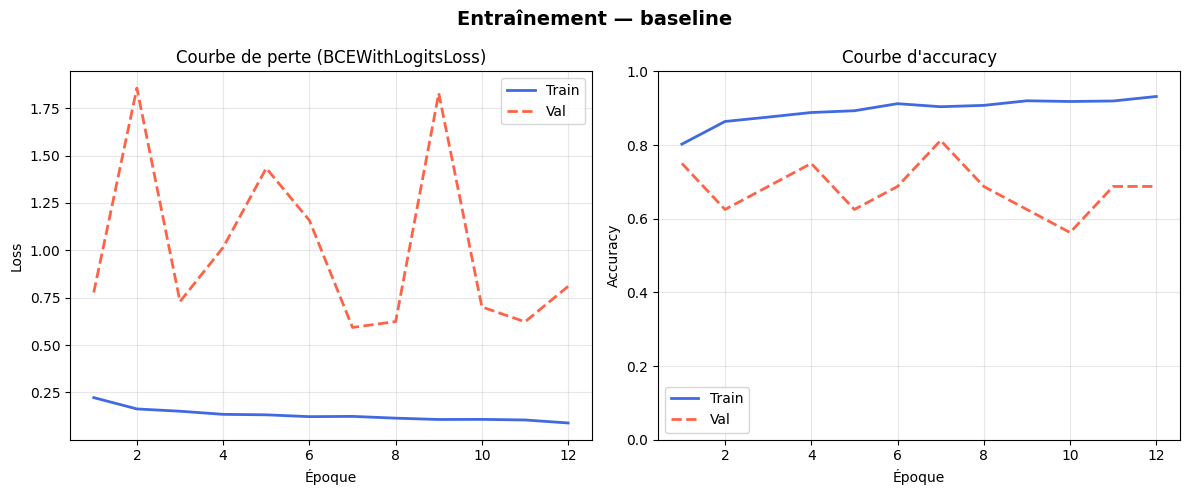

Saved → outputs/figures/training_curves.png


In [5]:
epochs_range = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, train_losses, label='Train', color='royalblue', linewidth=2)
axes[0].plot(epochs_range, val_losses,   label='Val',   color='tomato', linestyle='--', linewidth=2)
axes[0].set_title('Courbe de perte (BCEWithLogitsLoss)', fontsize=12)
axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, train_accs, label='Train', color='royalblue', linewidth=2)
axes[1].plot(epochs_range, val_accs,   label='Val',   color='tomato', linestyle='--', linewidth=2)
axes[1].set_title('Courbe d\'accuracy', fontsize=12)
axes[1].set_xlabel('Époque'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Entraînement — {CONFIG["arch"]}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/training_curves.png', dpi=150)
plt.show()
print('Saved → outputs/figures/training_curves.png')